This workbook aims to implement generalised profiling. 
Let's set it up and do each iteration by hand. 
The example will be to do with Newton's law of Cooling - as in Simpson and Baker (2026) SIAM Review

In the first instance let's do the same thing as Ramsay and Hooker (i.e. work with two weights and a least--squares framework).

Once we are happy with this we can generalise.

Matthew J Simpson - QUT

Ruth E Baker - Oxford

November 2025

In [1]:
using Plots, DifferentialEquations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Statistics
using SparseArrays, StatsAPI, LinearAlgebra
gr(); #Load packages 

In [2]:
Tend = 100; #End of time horizon
t=LinRange(0,Tend,11); #Discretised time variable, coarse discretisation for data
tf=LinRange(0,Tend,1001); #Discretised time variable, fine discretisation for ODE enforcing
int = 10; #When plotting we just plot every int-th data point,
t_exact(time) = 25 + (180-25)*exp(-0.05*time)
dt_exact(time) = -0.05*(180-25)*exp(-0.05*time)
data = [172.52963098608188
 131.2870617461668
  73.56389927679663
  62.939375577813976
  38.8392461185434
  38.665760026684474
  21.212445277871357
  37.2698938900581
  27.017801397794816
  24.652496127526355
  28.03908867548565];

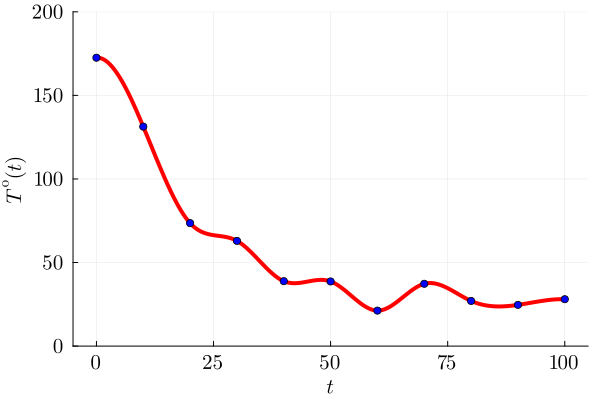

In [3]:
S_interp = interpolate(t, data, BSplineOrder(4)) #Create spline to overfit the data
B = basis(S_interp);       #Extract basis functions
Coeff = coefficients(S_interp) #Extract coefficients to fit the data

Csp = collocation_matrix(B, t, Derivative(0), SparseMatrixCSC{Float64, Int}); #Collocation matrix for the function on the coarse grid
Cspf = collocation_matrix(B, tf, Derivative(0), SparseMatrixCSC{Float64, Int}); #Collocation matrix for the function on the fine grid
C1spf = collocation_matrix(B, tf, Derivative(1), SparseMatrixCSC{Float64, Int}); #Collocation matrix for the first derivative on the fine grid

Temp  = Csp*Coeff; Tempf  = Cspf*Coeff; dTf = C1spf*Coeff; 

p1 = plot(tf,Tempf,lw=4,lc=:red,label=false)
p1=scatter!(t,data,mc=:blue,msc=:match,label=false)
p1=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

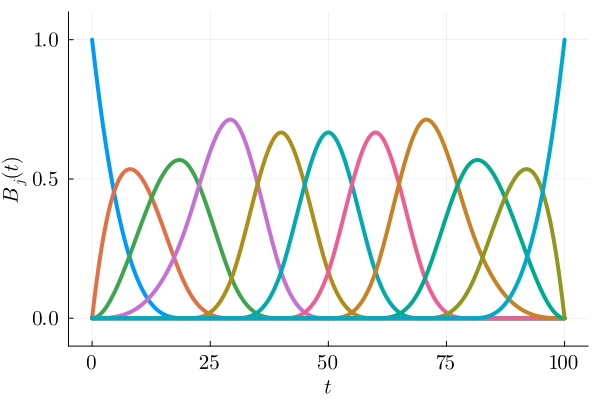

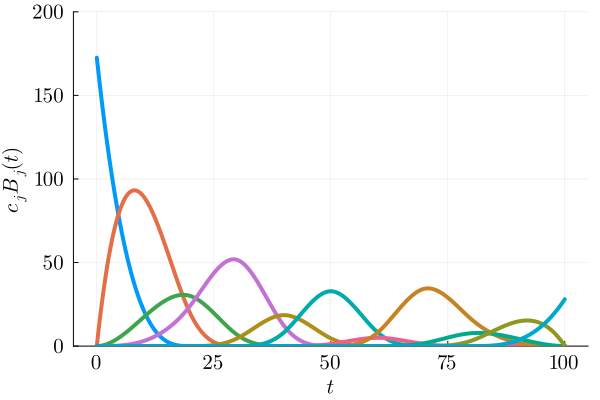

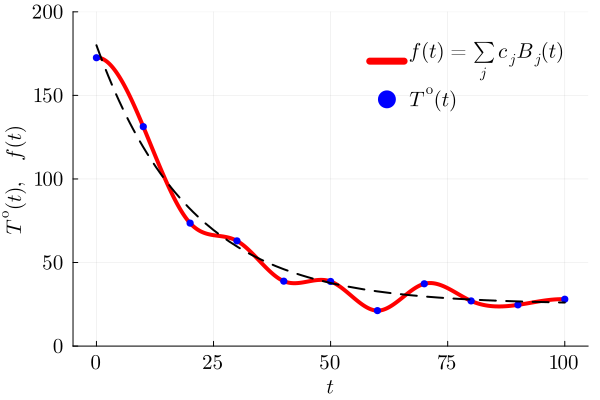

"C:\\Users\\matth\\Dropbox\\Generalised Profiling\\Notebooks\\fa.svg"

In [4]:
Csp = collocation_matrix(B, tf, Derivative(0), SparseMatrixCSC{Float64, Int})  # size = (length(tf), nbasis)

# Plot all basis functions
pB = plot(; xlabel=L"t", ylabel=L"B_j(t)",
          xlims=(tf[1]-5, tf[end]+5))

for j in 1:length(t)
    plot!(pB, tf, Csp[:, j],lw=4,label=false)
end
pB=plot!(xlabel=L"t",ylabel=L"B_j(t)",xlims=(t[1]-5,t[end]+5), ylims=(-0.1,1.1),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0.0,0.5,1.0],[L"0.0", L"0.5", L"1.0"]),label=false)
pB=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(pB)
savefig("fb.svg")

pBscaled = plot(; xlabel=L"t", ylabel=L"c_j B_j(t)",
          xlims=(tf[1]-5, tf[end]+5))

for j in 1:length(t)
    plot!(pBscaled, tf, Coeff[j]*Csp[:, j],lw=4,label=false)
end
pBscaled=plot!(xlabel=L"t",ylabel=L"c_j B_j(t)",xlims=(t[1]-5,t[end]+5),  ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
pBscaled=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(pBscaled)
savefig("fc.svg")

p1 = plot(tf,Tempf,lw=4,lc=:red,label=L"f(t) = \sum_j \, c_j B_j(t)")
p1=scatter!(t,data,mc=:blue,msc=:blue,label=L"T^{\textrm{o}}(t)")
p1 = plot!(t_exact,0,Tend,lc=:black, lw=2, ls=:dash,label=false)
p1=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t), \quad f(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]))
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14, legend = :topright, background_color_legend = :transparent,
    foreground_color_legend = :transparent, legendfontsize = 14)
display(p1)
savefig("fa.svg")

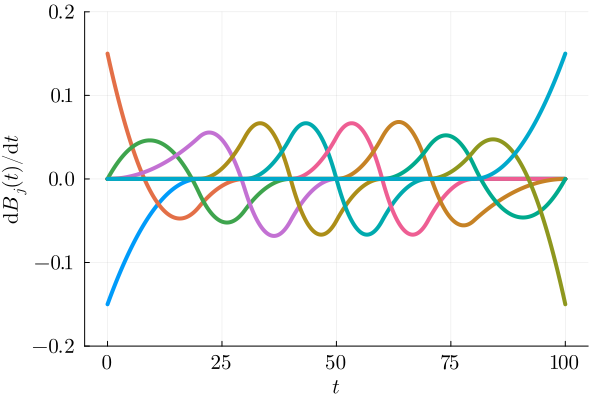

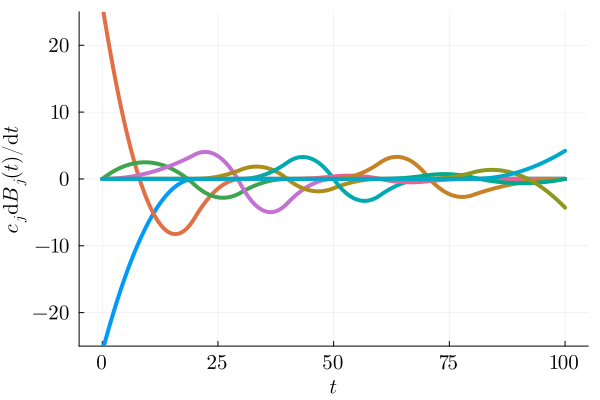

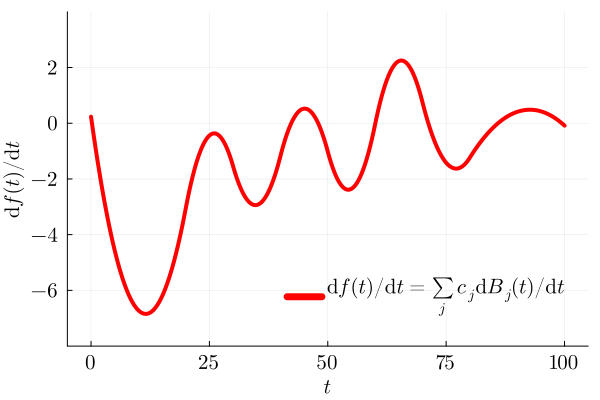

"C:\\Users\\matth\\Dropbox\\Generalised Profiling\\Notebooks\\f2c.svg"

In [5]:
Csp_deriv = collocation_matrix(B, tf, Derivative(1), SparseMatrixCSC{Float64, Int})  # size = (length(tf), nbasis)

# Plot all basis functions
pB = plot(; xlabel=L"t", ylabel=L"\textrm{d}B_j(t)/\textrm{d}t",
          xlims=(tf[1]-5, tf[end]+5))

for j in 1:length(t)
    plot!(pB, tf, Csp_deriv[:, j],lw=4,label=false)
end
pBd=plot!(xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
pBd=plot!(ylims=(-0.20,0.20),yticks = ([-0.20,-0.10,0.0,0.10,0.20],[L"-0.2", L"-0.1", L"0.0", L"0.1", L"0.2"]),label=false)
pBd=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(pBd)
savefig("f2a.svg")

pBscaledd = plot(; xlabel=L"t", ylabel=L"c_j \textrm{d}B_j(t)/\textrm{d}t",
          xlims=(tf[1]-5, tf[end]+5))

for j in 1:length(t)
    plot!(pBscaledd, tf, Coeff[j]*Csp_deriv[:, j],lw=4,label=false)
end
pBscaledd=plot!(xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
pBdscaled=plot!(ylims=(-25,25),yticks = ([-20,-10,0,10,20],[L"-20", L"-10", L"0", L"10", L"20"]),label=false)
pBscaledd=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(pBscaledd)
savefig("f2b.svg")

p1d = plot(tf,dTf,lw=4,lc=:red,label=L"\textrm{d}f(t)/\textrm{d}t = \sum_j \, c_j \textrm{d}B_j(t)/\textrm{d}t")
p1d=plot!(xlabel=L"t",ylabel=L"\textrm{d}f(t)/\textrm{d}t",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]))
p1d=plot!(ylims=(-8,4),yticks = ([-6,-4,-2,0,2],[L"-6", L"-4", L"-2", L"0", L"2"]),label=false)
p1d=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14, legend = :bottomright, background_color_legend = :transparent,
    foreground_color_legend = :transparent, legendfontsize = 14)
display(p1d)
savefig("f2c.svg")

In [6]:
function loglhood(data,T,Tf,dTf,t,tf,w,a) #Function to evaluate the loglikelihood of the data stored in the vector data. 
    
ℓ =0; ℓd =0; ℓm =0;    
dist=Normal(0,a[3]) 
ℓd+=loglikelihood(dist,data-T)  
ℓm = sum((dTf .+ a[2] .* (Tf.- a[1])).^2) / length(tf) 
ℓ = w[1]*ℓd - w[2]*ℓm;
return ℓ

end;

In [7]:
function Optimise(fun,θ₀,lb,ub) # Optimize finds the values of parameters \theta that maximise the objective function fun with lower bounds lb, and upper bounds ub
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=1*60
    res = optimize(opt,θ₀)
    return res[[2,1]]
end

Optimise (generic function with 1 method)

In [8]:
Tamin=0; Tamax=100; kmin=0; kmax=1; σmin = 0.1; σmax=50;  #Lower/upper bounds
θG=[20, 0.05, 2.0] #Iniitial estimate of the parameter values
lb=[Tamin,kmin,σmin]
ub=[Tamax,kmax,σmax]
a = zeros(3)
funopt(a) = loglhood(data,Temp,Tempf,dTf, t, tf, [1.0,1.0], a) #Here setting the weight to one
(θ0,fopt)=Optimise(funopt,θG,lb,ub) #Call to NLopt 

([17.229187817019827, 0.037572858325402095, 0.1], 12.532808546634111)

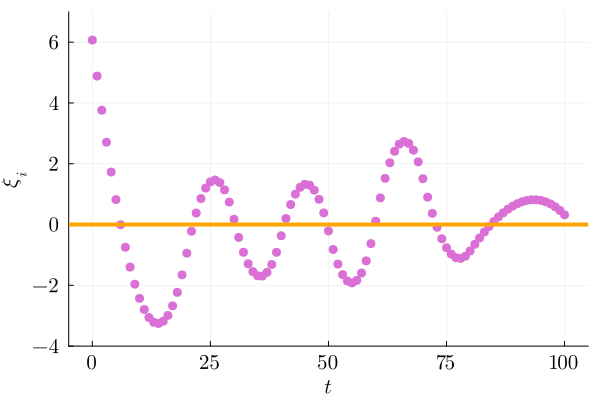

In [9]:
a1 = scatter(tf[1:int:end], (dTf.+ θ0[2].*(Tempf.-θ0[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a1 = hline!([0.0],lw=4,legend=false,lc=:orange)
a1=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [10]:
ℓd=0
ℓd+=loglikelihood(Normal(0,θ0[3]) ,data-Temp)  
ℓm =0
ℓm = sum((dTf .+ a[2] .* (Tempf .- a[1])).^2) / length(tf) 
w = [1.0,abs(1/ℓm)];

In [11]:
funopt1(a) = loglhood(data,Temp,Tempf,dTf, t, tf,w, a) #Here setting the weight to one
(θ1,fopt)=Optimise(funopt1,θG,lb,ub) #Call to NLopt 

([17.22918841104338, 0.037572858314999014, 0.1], 14.84641224521119)

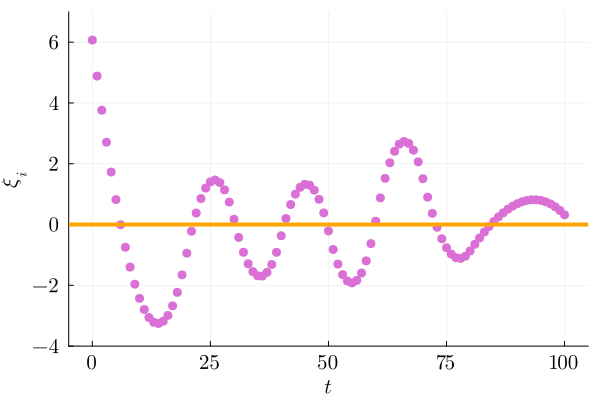

In [12]:
a2 = scatter(tf[1:int:end], (dTf.+ θ1[2].*(Tempf.-θ1[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a2 = hline!([0.0],lw=4,legend=false,lc=:orange)
a2=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a2=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [13]:
d1=zeros(length(tf)); d0=zeros(length(t))
d0=data;
d1 = [-θ1[2] * (Tempf[i] - θ1[1]) for i in eachindex(tf)]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p2 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p2=scatter!(t,data,mc=:blue,msc=:match,label=false)
p2=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p2=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p2)

LoadError: DimensionMismatch: size(F) = (2002, 11) but size(B) = (1012,)

In [ ]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ1[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ1[2] .* (Tempf .- θ1[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

In [ ]:
funopt2(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ2,fopt)=Optimise(funopt2,θG,lb,ub) #Call to NLopt 

In [ ]:
a3 = scatter(tf[1:int:end], (dTf.+ θ2[2].*(Tempf.-θ2[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a3 = hline!([0.0],lw=4,legend=false,lc=:orange)
a3=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a3=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [ ]:
d1=zeros(length(tf)); d0=zeros(length(t))
d0=data;
d1 = [-θ2[2] * (Tempf[i] - θ2[1]) for i in eachindex(tf)]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p3 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p3=scatter!(t,data,mc=:blue,msc=:match,label=false)
p3=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p3=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p3)

In [ ]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ2[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ2[2] .* (Tempf .- θ2[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

In [ ]:
funopt3(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ3,fopt)=Optimise(funopt3,θG,lb,ub) #Call to NLopt 

In [ ]:
a4 = scatter(tf[1:int:end], (dTf.+ θ3[2].*(Tempf.-θ3[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a4 = hline!([0.0],lw=4,legend=false,lc=:orange)
a4=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [ ]:
d1=zeros(length(tf)); d0=zeros(length(t))
d0=data;
d1 = [-θ3[2] * (Tempf[i] - θ3[1]) for i in eachindex(tf)]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:match,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [ ]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ3[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ3[2] .* (Tempf .- θ3[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

In [ ]:
funopt4(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ4,fopt)=Optimise(funopt4,θG,lb,ub) #Call to NLopt 

In [ ]:
a5 = scatter(tf[1:int:end], (dTf.+ θ4[2].*(Tempf.-θ4[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a5 = hline!([0.0],lw=4,legend=false,lc=:orange)
a5=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a5=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [ ]:
d1=zeros(length(tf)); d0=zeros(length(t))
d0=data;
d1 = [-θ4[2] * (Tempf[i] - θ4[1]) for i in eachindex(tf)]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p5 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p5=scatter!(t,data,mc=:blue,msc=:match,label=false)
p5=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p5=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p5)

In [ ]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ4[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ4[2] .* (Tempf .- θ4[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

In [ ]:
funopt5(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ5,fopt)=Optimise(funopt5,θG,lb,ub) #Call to NLopt 

In [ ]:
a6 = scatter(tf[1:int:end], (dTf.+ θ5[2].*(Tempf.-θ5[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a6 = hline!([0.0],lw=4,legend=false,lc=:orange)
a6=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a6=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [ ]:
d1=zeros(length(tf)); d0=zeros(length(t))
d0=data;
d1 = [-θ5[2] * (Tempf[i] - θ5[1]) for i in eachindex(tf)]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p6 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p6=scatter!(t,data,mc=:blue,msc=:match,label=false)
p6=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p6=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p6)

In [ ]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ5[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ5[2] .* (Tempf .- θ5[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

In [ ]:
funopt6(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ6,fopt)=Optimise(funopt6,θG,lb,ub) #Call to NLopt 

In [ ]:
a7 = scatter(tf[1:int:end], (dTf.+ θ6[2].*(Tempf.-θ6[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a7 = hline!([0.0],lw=4,legend=false,lc=:orange)
a7=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a7=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [ ]:
d1=zeros(length(tf)); d0=zeros(length(t))
d0=data;
d1 = [-θ6[2] * (Tempf[i] - θ6[1]) for i in eachindex(tf)]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p7 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p7=scatter!(t,data,mc=:blue,msc=:match,label=false)
p7=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p7=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p7)

In [ ]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ6[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ6[2] .* (Tempf .- θ6[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

In [ ]:
funopt7(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ7,fopt)=Optimise(funopt7,θG,lb,ub) #Call to NLopt 

In [ ]:
a8 = scatter(tf[1:int:end], (dTf.+ θ7[2].*(Tempf.-θ7[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a8 = hline!([0.0],lw=4,legend=false,lc=:orange)
a8=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a8=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [ ]:
d1=zeros(length(tf)); d0=zeros(length(t))
d0=data;
d1 = [-θ7[2] * (Tempf[i] - θ7[1]) for i in eachindex(tf)]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p8 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p8=scatter!(t,data,mc=:blue,msc=:match,label=false)
p8=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p8=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p8)

In [ ]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ7[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ7[2] .* (Tempf .- θ7[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

In [ ]:
funopt8(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ8,fopt)=Optimise(funopt8,θG,lb,ub) #Call to NLopt "

In [ ]:
a9 = scatter(tf[1:int:end], (dTf.+ θ8[2].*(Tempf.-θ8[1]))[1:int:end], ms=5,marker=:circle,color=:orchid,msc=:orchid,legend=false)
a9 = hline!([0.0],lw=4,legend=false,lc=:orange)
a9=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a9=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [ ]:
d1=zeros(length(tf)); d0=zeros(length(t))
d0=data;
d1 = [-θ8[2] * (Tempf[i] - θ8[1]) for i in eachindex(tf)]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p9 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p9=scatter!(t,data,mc=:blue,msc=:match,label=false)
p9=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p9=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p9)

In [ ]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ8[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ8[2] .* (Tempf .- θ8[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

In [ ]:
funopt9(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ9,fopt)=Optimise(funopt9,θG,lb,ub) #Call to NLopt "

In [ ]:
T0 = Tempf[1];
T_exact(t) = (T0-θ9[1])*exp(-θ9[2]*t)+θ9[1];

In [ ]:
p10 = plot(tf,Tempf; lw=4,lc=:red,label=false)
p10=scatter!(t,data,mc=:blue,msc=:match,label=false)
p10=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p10=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
p10=plot!(T_exact,0,Tend,lw=4,lc=:green,ls=:dash,legend=false)
display(p10)

In [ ]:
l1=plot(p1,a1,layout=(1,2))
savefig("f1.svg")

In [ ]:
l2=plot(p2,a2,layout=(1,2))
savefig("f2.svg")

In [ ]:
l3=plot(p3,a3,layout=(1,2))
savefig("f3.svg")

In [ ]:
l4=plot(p4,a4,layout=(1,2))
savefig("f4.svg")